In [1]:
# @title Package
from natsort import natsorted
import numpy as np
import seaborn as sns
import pandas as pd

import matplotlib.pyplot as plt
import os

import torch
import torch.nn as nn
import torch.nn.functional as F
import scipy as sp
import scipy.signal as signal
import torchaudio
import math
from sklearn import svm

import torchvision
import torchvision.transforms as transforms
import torchaudio.models as audio_models

from torch.utils.data import DataLoader
from torch.utils.data import TensorDataset

import time

lib_dir = '/content/drive/MyDrive/Project/BrainRegionId/Project44/Code'
os.chdir(lib_dir)
print('library directory: ' + lib_dir)
from modules.networks_clf import *
from modules.signal import spectro_norm, lfp_spectro
from modules.data import *
from modules.metrics import accu_fun

library directory: /content/drive/MyDrive/Project/BrainRegionId/Project44/Code


In [2]:
# @title Load device
dtype = torch.float
# Check whether GPU is available
if torch.cuda.is_available():
    device = torch.device('cuda')
else:
    device = torch.device('cpu')

!nvidia-smi -L


/bin/bash: line 1: nvidia-smi: command not found


In [3]:
# Set the signal parameters
spectro_args = {
    'nfft':800,
    'power':1,
    'LFP_bound':[0, 500],
    'MUA_bound':[500, 2000],
    'spectro_img':[224, 28],
    'LFP_img':[56 * 4, 28],
    'MUA_img':[0, 28],
    'sampling_lfp':2500,
    'sampling_mua':5000,
    'Log':False,
}

dict_dir = '/content/drive/MyDrive/Project/BrainRegionId/Project37/Data/dat'
acronym_list = acronym_list_gen(dict_dir)

In [4]:
communities_accu = torch.load('/content/drive/MyDrive/Project/BrainRegionId/Science/results/communities/communities_accu.pt', weights_only=False)

In [5]:
community_dict = torch.load('/content/drive/MyDrive/Project/BrainRegionId/Science/results/communities/community_dict.pt', weights_only=False)

In [ ]:
community_dict

{0.4: {'communities': array([  3,   4,   5,   6,   7,   8,   9,  10,  11,  12,  13,  15,  16,
          17,  18,  19,  22,  23,  24,  25,  26,  27,  28,  29,  30,  31,
          33,  34,  35,  36,  37,  38,  39,  40,  41,  42,  43,  44,  45,
          46,  47,  48,  49,  50,  51,  52,  53,  54,  55,  59,  60,  61,
          62,  64,  65,  81,  87,  88,  89,  90,  91,  92,  93,  94,  95,
          97,  98,  99, 100, 101, 102, 103, 104, 107, 108, 109, 110, 111,
         112, 113, 114, 115, 116, 117, 118, 119, 120, 123, 124, 125, 127,
         128, 129, 130, 131, 132, 133, 134, 137, 138, 139, 140, 141, 142,
         143, 149, 150, 151, 155, 156, 157, 158, 159, 162, 163, 164, 165,
         166, 167, 168, 169, 170, 171, 173, 174, 175, 176, 178, 179, 180,
         181, 182, 183, 184, 185, 186, 187, 188, 191, 192, 193, 194, 199,
         206, 212, 213, 217, 218, 220, 221, 222, 223, 224, 225, 226, 227,
         228, 231, 234, 235, 236, 237, 238, 239, 240, 241, 242, 243, 244,
         246, 247,

In [ ]:
communities_accu[0.4]['cross-trial'].keys()

Index(['acu_test', 'model_type'], dtype='object')

In [ ]:
accu_test = []
model_type = []
resolution_list = []
community_number = []
label = []
for resolution in [0.4, 0.6, 0.8, 1.0, 1.2]:
    for ii in range(0, len(communities_accu[resolution]['cross-trial']['acu_test'])):
        accu_test.append(communities_accu[resolution]['cross-trial']['acu_test'][ii])
        model_type.append(communities_accu[resolution]['cross-trial']['model_type'][ii])
        resolution_list.append(resolution)
        community_number.append(len(np.unique(community_dict[resolution]['communities_label'])))
        n = len(np.unique(community_dict[resolution]['communities_label']))
        label.append(f'{resolution} ({n})')

cross_trial_dict = pd.DataFrame({
    'resolution': np.array(resolution_list),
    'cross-trial accuracy': np.array(accu_test),
    'model': np.array(model_type),
    'community number': np.array(community_number),
    'resolution (communities)': np.array(label)
})

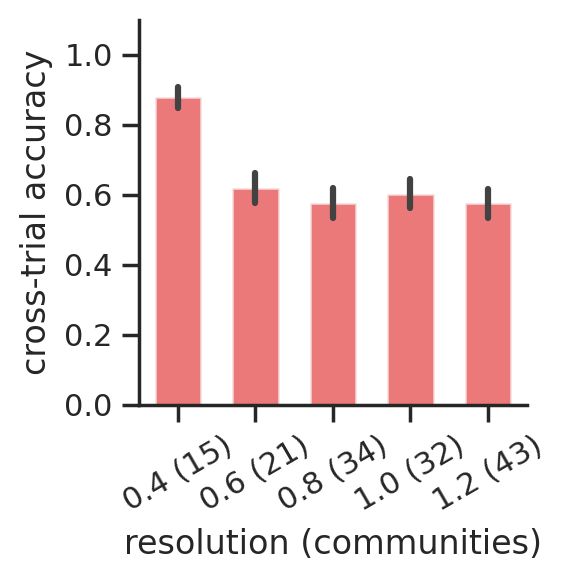

In [ ]:
sns.set_theme(style='ticks')
color_list = sns.color_palette('colorblind')
plt.figure(figsize=(2.5, 2.5), dpi=200)
g = sns.barplot(
    data=cross_trial_dict[cross_trial_dict['model'] == 'AnyNet'],
    x='resolution (communities)', y='cross-trial accuracy',
    errorbar='sd', width=0.6, color='red', alpha=.6
)
plt.ylim([0, 1.1])
plt.xticks(rotation=30)
plt.ylabel('cross-trial accuracy')
plt.xlabel('resolution (communities)')
sns.despine()
plt.show()
# plt.legend(loc='lower left')
# plt.title(f'Community (cross-trial test)')

/tmp/ipython-input-9-3851767550.py:4: UserWarning: The palette list has more values (10) than needed (3), which may not be intended.
  g = sns.barplot(
/tmp/ipython-input-9-3851767550.py:19: UserWarning: The palette list has more values (10) than needed (3), which may not be intended.
  g = sns.barplot(


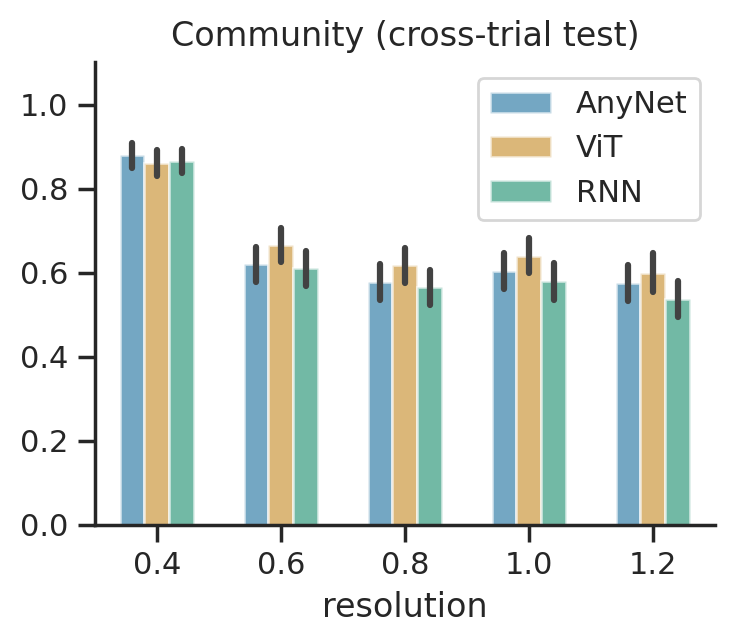

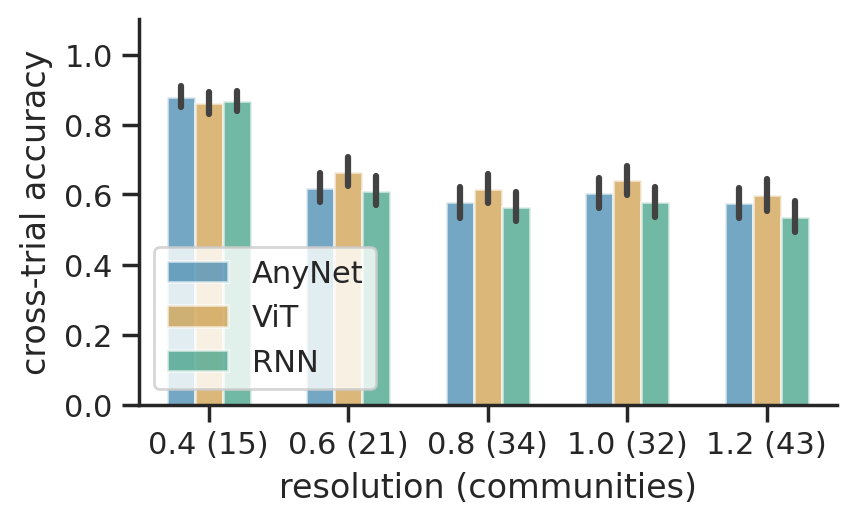

In [ ]:
sns.set_theme(style='ticks')
color_list = sns.color_palette('colorblind')
plt.figure(figsize=(4, 3), dpi=200)
g = sns.barplot(
    data=cross_trial_dict,
    x='resolution', y='cross-trial accuracy', hue='model',
    errorbar='sd', width=0.6, palette=color_list, alpha=.6
)
plt.ylim([0, 1.1])
plt.ylabel('')
plt.xlabel('resolution')
sns.despine()
plt.legend(loc='best')
plt.title(f'Community (cross-trial test)')

sns.set_theme(style='ticks')
color_list = sns.color_palette('colorblind')
plt.figure(figsize=(4.5, 2.5), dpi=200)
g = sns.barplot(
    data=cross_trial_dict,
    x='resolution (communities)', y='cross-trial accuracy', hue='model',
    errorbar='sd', width=0.6, palette=color_list, alpha=.6
)
plt.ylim([0, 1.1])
plt.ylabel('cross-trial accuracy')
plt.xlabel('resolution (communities)')
sns.despine()
plt.legend(loc='lower left')
# plt.title(f'Community (cross-trial test)')

In [ ]:
accu_test_subject = []
model_type_subject = []
resolution_list_subject = []
label_subject = []
for resolution in [0.4, 0.6, 0.8, 1.0, 1.2]:
    for ii in range(0, len(communities_accu[resolution]['cross-subject']['acu_test'])):
        accu_test_subject.append(communities_accu[resolution]['cross-subject']['acu_test'][ii])
        model_type_subject.append(communities_accu[resolution]['cross-subject']['model_type'][ii])
        resolution_list_subject.append(resolution)
        n = len(np.unique(community_dict[resolution]['communities_label']))
        label_subject.append(f'{resolution} ({n})')

cross_subject_dict = pd.DataFrame({
    'resolution': np.array(resolution_list_subject),
    'cross-subject accuracy': np.array(accu_test_subject),
    'model': np.array(model_type_subject),
    'resolution (communities)': np.array(label_subject)
})

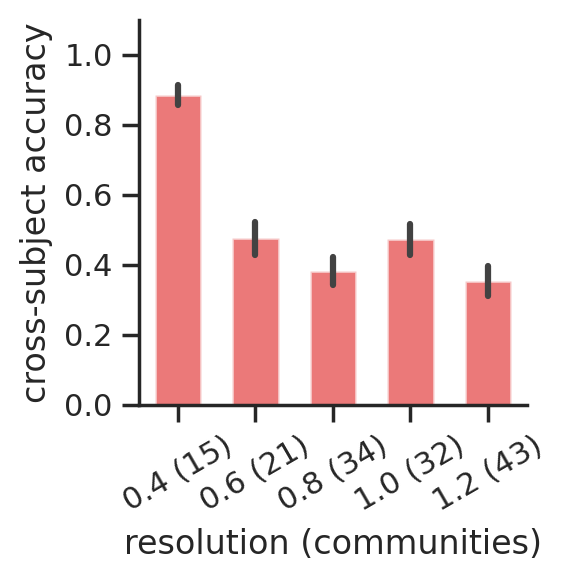

In [ ]:
sns.set_theme(style='ticks')
color_list = sns.color_palette('colorblind')
plt.figure(figsize=(2.5, 2.5), dpi=200)
g = sns.barplot(
    data=cross_subject_dict[cross_subject_dict['model'] == 'AnyNet'],
    x='resolution (communities)', y='cross-subject accuracy',
    errorbar='sd', width=0.6, color='red', alpha=.6
)
plt.ylim([0, 1.1])
plt.xticks(rotation=30)
plt.ylabel('cross-subject accuracy')
plt.xlabel('resolution (communities)')
sns.despine()
plt.show()
# plt.title(f'Community (cross-subject test)')

/tmp/ipython-input-11-2896165118.py:4: UserWarning: The palette list has more values (10) than needed (3), which may not be intended.
  g = sns.barplot(
/tmp/ipython-input-11-2896165118.py:19: UserWarning: The palette list has more values (10) than needed (3), which may not be intended.
  g = sns.barplot(


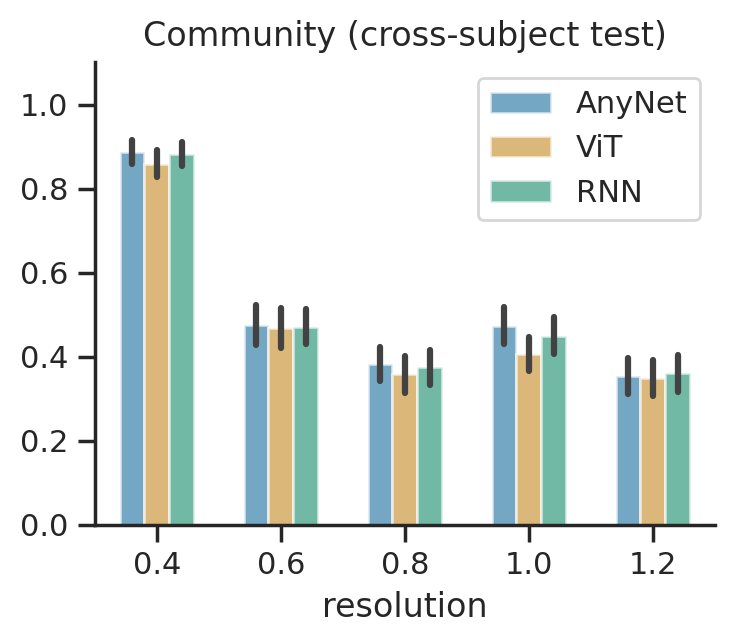

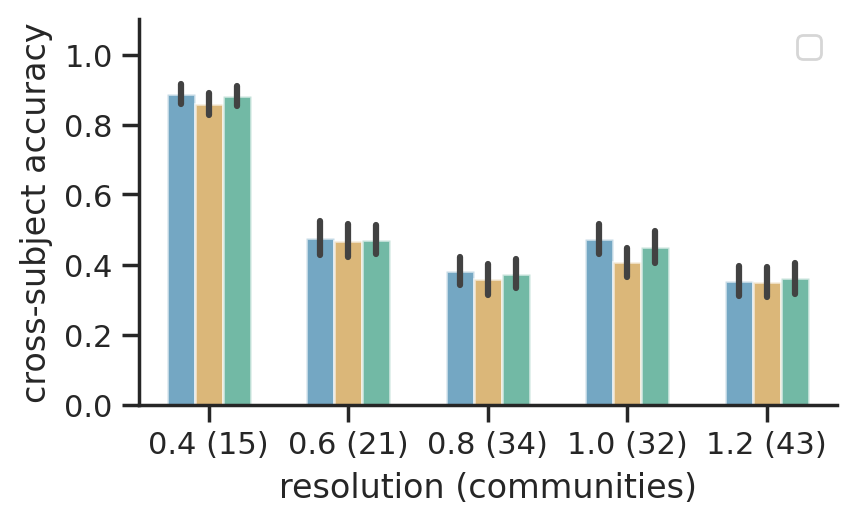

In [ ]:
sns.set_theme(style='ticks')
color_list = sns.color_palette('colorblind')
plt.figure(figsize=(4, 3), dpi=200)
g = sns.barplot(
    data=cross_subject_dict,
    x='resolution', y='cross-subject accuracy', hue='model',
    errorbar='sd', width=0.6, palette=color_list, alpha=.6
)
plt.ylim([0, 1.1])
plt.ylabel('')
plt.xlabel('resolution')
sns.despine()
plt.legend(loc='best')
plt.title(f'Community (cross-subject test)')

sns.set_theme(style='ticks')
color_list = sns.color_palette('colorblind')
plt.figure(figsize=(4.5, 2.5), dpi=200)
g = sns.barplot(
    data=cross_subject_dict,
    x='resolution (communities)', y='cross-subject accuracy', hue='model',
    errorbar='sd', width=0.6, palette=color_list, alpha=.6
)
plt.ylim([0, 1.1])
plt.ylabel('cross-subject accuracy')
plt.xlabel('resolution (communities)')
sns.despine()
plt.legend([])
# plt.title(f'Community (cross-subject test)')

In [ ]:
Cosmos_accu_dict = torch.load('/content/drive/MyDrive/Project/BrainRegionId/Science/results/accu/Cosmos_dict.pt', weights_only=False)

In [ ]:
def barplot_annotate_brackets(num1, num2, data, center, height, yerr=None, dh=.05, barh=.05, fs=None, maxasterix=None):
    """
    Annotate barplot with p-values.

    :param num1: number of left bar to put bracket over
    :param num2: number of right bar to put bracket over
    :param data: string to write or number for generating asterixes
    :param center: centers of all bars (like plt.bar() input)
    :param height: heights of all bars (like plt.bar() input)
    :param yerr: yerrs of all bars (like plt.bar() input)
    :param dh: height offset over bar / bar + yerr in axes coordinates (0 to 1)
    :param barh: bar height in axes coordinates (0 to 1)
    :param fs: font size
    :param maxasterix: maximum number of asterixes to write (for very small p-values)
    """

    if type(data) is str:
        text = data
    else:
        # * is p < 0.01
        # ** is p < 0.001
        # *** is p < 0.0001
        # etc.
        text = ''
        p = .01

        while data < p:
            text += '*'
            p /= 10.

            if maxasterix and len(text) == maxasterix:
                break

        if len(text) == 0:
            text = 'n. s.'

    lx, ly = center[num1], height[num1]
    rx, ry = center[num2], height[num2]

    if yerr:
        ly += yerr[num1]
        ry += yerr[num2]

    ax_y0, ax_y1 = plt.gca().get_ylim()
    dh *= (ax_y1 - ax_y0)
    barh *= (ax_y1 - ax_y0)

    y = max(ly, ry) + dh

    barx = [lx, lx, rx, rx]
    bary = [y, y+barh, y+barh, y]
    mid = ((lx+rx)/2, y+barh)

    plt.plot(barx, bary, c='black')

    kwargs = dict(ha='center', va='bottom')
    if fs is not None:
        kwargs['fontsize'] = fs

    plt.text(*mid, text, **kwargs)

/tmp/ipython-input-5-1240991367.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  g = sns.barplot(
/tmp/ipython-input-5-1240991367.py:23: UserWarning: The palette list has more values (7) than needed (5), which may not be intended.
  g = sns.barplot(


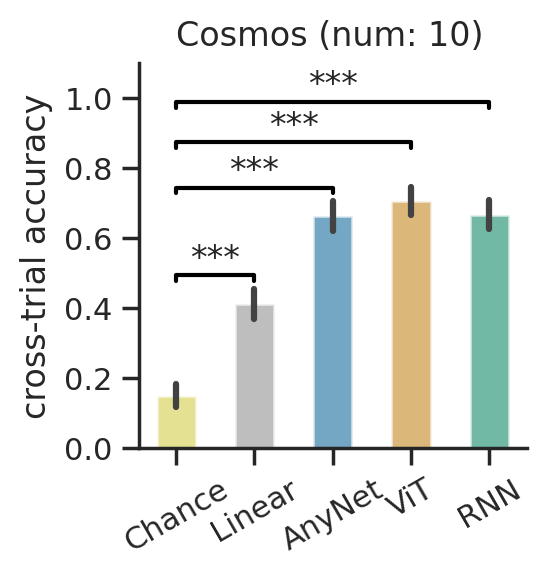

In [ ]:
color_list = sns.color_palette('colorblind')
color_list_define = []
color_list_define.append(color_list[-2])
color_list_define.append(color_list[-3])
for ii in range(0, 5):
    color_list_define.append(color_list[ii])

_, p_cl = sp.stats.ttest_ind(np.array(Cosmos_accu_dict[Cosmos_accu_dict['model_type'] == 'Chance']['acu_test']),
                   np.array(Cosmos_accu_dict[Cosmos_accu_dict['model_type'] == 'Linear']['acu_test']), equal_var=False)

_, p_la = sp.stats.ttest_ind(np.array(Cosmos_accu_dict[Cosmos_accu_dict['model_type'] == 'Linear']['acu_test']),
                   np.array(Cosmos_accu_dict[Cosmos_accu_dict['model_type'] == 'AnyNet']['acu_test']), equal_var=False)

_, p_lv = sp.stats.ttest_ind(np.array(Cosmos_accu_dict[Cosmos_accu_dict['model_type'] == 'Linear']['acu_test']),
                   np.array(Cosmos_accu_dict[Cosmos_accu_dict['model_type'] == 'ViT']['acu_test']), equal_var=False)

_, p_lr = sp.stats.ttest_ind(np.array(Cosmos_accu_dict[Cosmos_accu_dict['model_type'] == 'Linear']['acu_test']),
                   np.array(Cosmos_accu_dict[Cosmos_accu_dict['model_type'] == 'RNN']['acu_test']), equal_var=False)

sns.set_theme(style='ticks')
color_list = sns.color_palette('colorblind')
plt.figure(figsize=(2.5, 2.5), dpi=200)
g = sns.barplot(
    data=Cosmos_accu_dict,
    x='model_type', y='acu_test',
    errorbar='sd', width=0.5, palette=color_list_define, alpha=.6
)

barplot_annotate_brackets(1, 2, p_cl, np.array([0, 0, 1, 1]),
                          [0.2, 0.2, 0.4, 0.4], dh=0.1, barh=.02, maxasterix=3)
barplot_annotate_brackets(1, 2, p_la, np.array([0, 0, 2, 2]),
                          [0.2, 0.2, 0.65, 0.65], dh=0.1, barh=.02, maxasterix=3)
barplot_annotate_brackets(1, 2, p_cl, np.array([0, 0, 3, 3]),
                          [0.2, 0.2, 0.78, 0.78], dh=0.1, barh=.02, maxasterix=3)
barplot_annotate_brackets(1, 2, p_cl, np.array([0, 0, 4, 4]),
                          [0.2, 0.2, 0.88, 0.88], dh=0.1, barh=.02, maxasterix=3)

plt.ylim([0, 1.1])
plt.ylabel('cross-trial accuracy')
plt.xlabel('')
plt.xticks(rotation=30)
sns.despine()
plt.text(0, 1.15, 'Cosmos (num: 10)')
plt.show()

# sns.set_theme(style='ticks')
# color_list = sns.color_palette('colorblind')
# plt.figure(figsize=(2.5, 2.5), dpi=200)
# g = sns.barplot(
#     data=cross_trial_dict[cross_trial_dict['resolution'] == 1.0],
#     x='model', y='cross-trial accuracy',
#     errorbar='sd', width=0.6, palette=color_list, alpha=.6
# )
# plt.ylim([0, 1.1])
# plt.xlim([-2.5, 2.5])
# plt.xticks([-2, -1, 0, 1, 2], ['Chance', 'Linear', 'AnyNet', 'ViT', 'RNN'])
# plt.ylabel('cross-trial accuracy')
# plt.xlabel('')
# plt.xticks(rotation=30)
# sns.despine()
# plt.title(f'LFPs-based communities')
# plt.show()

In [6]:
communities_accu_indiv = torch.load('/content/drive/MyDrive/Project/BrainRegionId/Science/results/communities/communities_accu_indiv.pt', weights_only=False)

In [ ]:
communities_accu_indiv[0.4]

,acu_test,model_type,acronym_test,acronym_index_test
0,0.960938,AnyNet,0,0
1,0.953125,AnyNet,0,0
2,0.992188,AnyNet,0,0
3,0.953125,AnyNet,0,0
4,0.976562,AnyNet,0,0
...,...,...,...,...
4732,0.226562,ViT,14,14
4733,0.169355,ViT,14,14
4734,0.335938,RNN,14,14
4735,0.335938,RNN,14,14


In [7]:
resolution = 0.4

In [8]:
marked_community = []
for community in np.unique(community_dict[resolution]['communities_label']):
    df_indiv0 = communities_accu_indiv[resolution][communities_accu_indiv[resolution]['acronym_test'] == community]
    for classifier_name in ['AnyNet', 'ViT', 'RNN']:
        if df_indiv0[df_indiv0['model_type'] == classifier_name]['acu_test'].mean() > 0.00:
            marked_community.append(community)

marked_community = np.unique(np.array(marked_community))

In [9]:
marked_community

array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14])

/tmp/ipython-input-1672021321.py:4: UserWarning: The palette list has more values (10) than needed (3), which may not be intended.
  g = sns.barplot(


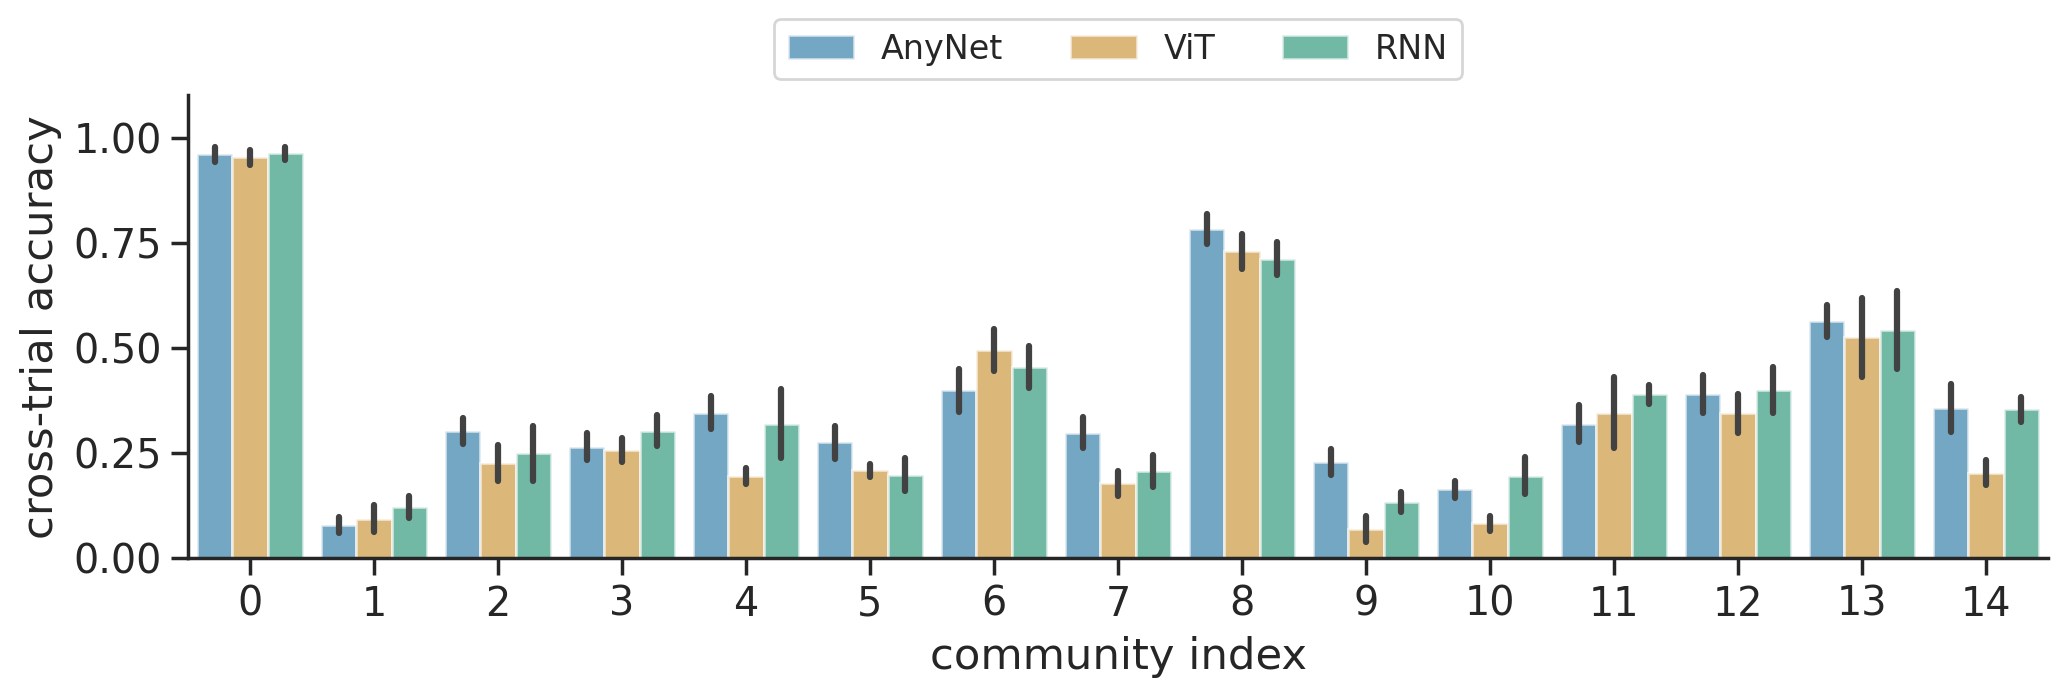

In [10]:
sns.set_theme(style='ticks', font_scale=1.3)
color_list = sns.color_palette('colorblind')
plt.figure(figsize=(12, 3), dpi=200)
g = sns.barplot(
    data=communities_accu_indiv[resolution],
    x='acronym_test', y='acu_test', hue='model_type',
    errorbar='sd', width=0.85, palette=color_list, alpha=.6
)
sns.move_legend(g, loc='lower center', bbox_to_anchor=(0.5, 1), ncol=3, title=None, fontsize=12)
# plt.plot([-0.5, 14.5], [0.6, 0.6], 'k--')
plt.xlim([-0.5, 14.5])
plt.ylim([0, 1.1])
plt.xticks(marked_community)
plt.ylabel('cross-trial accuracy')
plt.xlabel('community index')
sns.despine()
# plt.legend(loc='lower left')
plt.show()

In [ ]:
marked_community = []
for community in np.unique(community_dict[1.0]['communities_label']):
    df_indiv0 = communities_accu_indiv[1.0][communities_accu_indiv[1.0]['acronym_test'] == community]
    for classifier_name in ['AnyNet', 'ViT', 'RNN']:
        if df_indiv0[df_indiv0['model_type'] == classifier_name]['acu_test'].mean() > 0.50:
            marked_community.append(community)

marked_community = np.unique(np.array(marked_community))

In [ ]:
len(marked_community)

18

In [ ]:
community_dict[1.0]

{'communities': array([366, 380, 385, 386, 387, 388, 389, 390, 391, 393, 395, 396, 397,
        398, 399, 400, 401, 402, 403, 404, 405, 406, 407, 408, 409, 410,
        411, 413, 415, 417, 418, 419, 420, 454, 455, 456, 457, 458, 459,
        460, 461, 462, 463, 464, 465, 466, 467, 468, 469, 470, 471, 322,
        345, 369, 374, 375, 379,   3,   6,   7,   8,  12,  13,  33,  34,
         35,  36,  37,  61,  62, 127, 128, 129, 131, 132, 133, 134, 137,
        138, 139, 140, 141, 142, 143, 147, 150, 151, 155, 156, 157, 158,
        163, 164, 165, 166, 167, 226, 227, 236, 237,  99, 100, 101, 102,
        103, 108, 109, 116, 170, 171, 175, 176, 178, 225, 319, 320, 321,
         26,  27,  44,  87, 110, 111, 112, 113, 168, 169, 174, 177, 184,
        435,  22,  23, 105,  20,  21,  56,  57,  93,  94,  95,  96, 118,
        183, 195, 196, 146, 149, 425, 119, 199, 353, 120, 212, 217, 221,
        222, 223, 235, 267, 430, 431, 432, 433, 438,   0,   1, 144, 145,
        152, 153, 207, 208, 228, 422

In [ ]:
################################################################################
import subprocess
import sys
required = {'ONE-api', 'brain', 'ibllib'}
subprocess.check_call([sys.executable, '-m', 'pip', 'install', *required])

from one.api import ONE
from brainbox.io.one import SessionLoader, SpikeSortingLoader

from iblatlas.atlas import AllenAtlas

ba = AllenAtlas()
br = ba.regions
ba.compute_regions_volume()

In [ ]:
# from iblatlas.plots import plot_scalar_on_slice
# import matplotlib.colors as mcolors
# import matplotlib as mpl

In [ ]:
# ii = 0
# for indice in range(-5000, 100, 500):
#     fig, ax = plot_scalar_on_slice(community_dict[1.0]['communities_acronym'], community_dict[1.0]['communities_label'], coord=indice, slice='sagittal', mapping='Allen', hemisphere='all',
#                                 background='boundary', cmap='gist_ncar', brain_atlas=ba)
#     plt.axis('off')
#     # plt.title(f'resolution: {resolution}')
#     plt.title(f'sagittal indice: {indice}')

#     ii += 1

# jj = 0
# for indice in range(-5000, 100, 500):
#     fig, ax = plot_scalar_on_slice(community_dict[1.0]['communities_acronym'], community_dict[1.0]['communities_label'], coord=indice, slice='horizontal', mapping='Allen', hemisphere='all',
#                                 background='boundary', cmap='gist_ncar', brain_atlas=ba)
#     plt.axis('off')
#     # plt.title(f'resolution: {resolution}')
#     plt.title(f'horizontal indice: {indice}')

#     jj += 1

# kk = 0
# for indice in range(-5000, 100, 500):
#     fig, ax = plot_scalar_on_slice(community_dict[1.0]['communities_acronym'], community_dict[1.0]['communities_label'], coord=indice, slice='coronal', mapping='Allen', hemisphere='all',
#                                 background='boundary', cmap='gist_ncar', brain_atlas=ba)
#     plt.axis('off')
#     # plt.title(f'resolution: {resolution}')
#     plt.title(f'coronal indice: {indice}')

#     kk += 1

In [ ]:
acronym_list_Cosmos = [br.acronym2acronym(acronym, mapping='Cosmos')[0] for acronym in acronym_list]
acronym_list_Cosmos = np.array(acronym_list_Cosmos)

In [ ]:
selec_vis_community = []
selec_vis_label = []
for community in marked_community:
    print('community index>>>>>>>>>>>>>>>')
    print(community_dict[1.0]['communities_label'][np.argwhere(community_dict[1.0]['communities_label'] == community).flatten()])
    selec_vis_label.append(np.array(community_dict[1.0]['communities_label'][np.argwhere(community_dict[1.0]['communities_label'] == community).flatten()]))
    print('Allen>>>>>>>>>>>>>>>>>>>>>>>>>')
    print(community_dict[1.0]['communities_acronym'][np.argwhere(community_dict[1.0]['communities_label'] == community).flatten()])
    selec_vis_community.append(np.array(community_dict[1.0]['communities_acronym'][np.argwhere(community_dict[1.0]['communities_label'] == community).flatten()]))

    print('Cosmos>>>>>>>>>>>>>>>>>>>>>>>>')
    print(acronym_list_Cosmos[community_dict[1.0]['communities'][np.argwhere(community_dict[1.0]['communities_label'] == community).flatten()]])

selec_vis_community = np.concat(selec_vis_community)
selec_vis_label = np.concat(selec_vis_label)

community index>>>>>>>>>>>>>>>
[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
Allen>>>>>>>>>>>>>>>>>>>>>>>>>
['KF' 'I5' 'DCO' 'VCO' 'CU' 'ECU' 'SPVC' 'SPVI' 'Pa5' 'AMBv' 'GRN' 'ICB'
 'IO' 'IRN' 'LIN' 'LRNm' 'MARN' 'MDRNd' 'MDRNv' 'PARN' 'PAS' 'PGRNd'
 'PGRNl' 'PRP' 'LAV' 'MV' 'SPIV' 'x' 'y' 'FN' 'IP' 'DN' 'VeCB' 'NTS'
 'SPVO' 'LING' 'CENT2' 'CENT3' 'CUL4 5' 'DEC' 'FOTU' 'PYR' 'UVU' 'NOD'
 'SIM' 'ANcr1' 'ANcr2' 'PRM' 'COPY' 'PFL' 'FL']
Cosmos>>>>>>>>>>>>>>>>>>>>>>>>
['HB' 'HB' 'HB' 'HB' 'HB' 'HB' 'HB' 'HB' 'HB' 'HB' 'HB' 'HB' 'HB' 'HB'
 'HB' 'HB' 'HB' 'HB' 'HB' 'HB' 'HB' 'HB' 'HB' 'HB' 'HB' 'HB' 'HB' 'HB'
 'HB' 'CB' 'CB' 'CB' 'CB' 'HB' 'HB' 'CB' 'CB' 'CB' 'CB' 'CB' 'CB' 'CB'
 'CB' 'CB' 'CB' 'CB' 'CB' 'CB' 'CB' 'CB' 'CB']
community index>>>>>>>>>>>>>>>
[1 1 1 1 1 1]
Allen>>>>>>>>>>>>>>>>>>>>>>>>>
['ICc' 'CUN' 'SOCl' 'PRNc' 'SUT' 'PC5']
Cosmos>>>>>>>>>>>>>>>>>>>>>>>>
['MB' 'MB' 'HB' 'HB' 'HB' 'HB']
community index>>>>>>>>>>>>>>>
[2

In [ ]:
selec_vis_community

array(['KF', 'I5', 'DCO', 'VCO', 'CU', 'ECU', 'SPVC', 'SPVI', 'Pa5',
       'AMBv', 'GRN', 'ICB', 'IO', 'IRN', 'LIN', 'LRNm', 'MARN', 'MDRNd',
       'MDRNv', 'PARN', 'PAS', 'PGRNd', 'PGRNl', 'PRP', 'LAV', 'MV',
       'SPIV', 'x', 'y', 'FN', 'IP', 'DN', 'VeCB', 'NTS', 'SPVO', 'LING',
       'CENT2', 'CENT3', 'CUL4 5', 'DEC', 'FOTU', 'PYR', 'UVU', 'NOD',
       'SIM', 'ANcr1', 'ANcr2', 'PRM', 'COPY', 'PFL', 'FL', 'ICc', 'CUN',
       'SOCl', 'PRNc', 'SUT', 'PC5', 'FRP6a', 'MOp5', 'MOp6a', 'MOp6b',
       'MOs6a', 'MOs6b', 'SSp-m2/3', 'SSp-m4', 'SSp-m5', 'SSp-m6a',
       'SSp-m6b', 'GU5', 'GU6a', 'ACAd5', 'ACAd6a', 'ACAd6b', 'ACAv2/3',
       'ACAv5', 'ACAv6a', 'ACAv6b', 'PL5', 'PL6a', 'PL6b', 'ILA1',
       'ILA2/3', 'ILA5', 'ILA6a', 'ORBl6a', 'ORBm5', 'ORBm6a', 'ORBvl6a',
       'AId5', 'AId6a', 'AId6b', 'AIp6b', 'AIv2/3', 'AIv5', 'AIv6a',
       'AIv6b', 'CLA', 'EPd', 'CP', 'ACB', 'VISli6b', 'FC', 'ENTl5',
       'ENTm3', 'ENTm5', 'ENTm6', 'PA', 'MGd', 'TR', 'CA1', 'CA2', 'CA3',
   

In [ ]:
from iblatlas.plots import plot_scalar_on_slice
import matplotlib.colors as mcolors
import matplotlib as mpl

In [ ]:
cmap_selec = mpl.cm.get_cmap('tab20')

/tmp/ipython-input-87-2556972733.py:1: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap_selec = mpl.cm.get_cmap('tab20')


In [ ]:
ii = 0
for indice in range(-5000, 100, 500):
    fig, ax = plot_scalar_on_slice(selec_vis_community, 0.1 * selec_vis_label, coord=indice, slice='sagittal', mapping='Allen', hemisphere='all',
                                background='boundary', cmap=cmap_selec, brain_atlas=ba)
    plt.axis('off')
    # plt.title(f'resolution: {resolution}')
    plt.title(f'sagittal indice: {indice}')

    ii += 1

jj = 0
for indice in range(-5000, 100, 500):
    fig, ax = plot_scalar_on_slice(selec_vis_community, 0.1 * selec_vis_label, coord=indice, slice='horizontal', mapping='Allen', hemisphere='all',
                                background='boundary', cmap=cmap_selec, brain_atlas=ba)
    plt.axis('off')
    # plt.title(f'resolution: {resolution}')
    plt.title(f'horizontal indice: {indice}')

    jj += 1

kk = 0
for indice in range(-5000, 100, 500):
    fig, ax = plot_scalar_on_slice(selec_vis_community, 0.1 * selec_vis_label, coord=indice, slice='coronal', mapping='Allen', hemisphere='all',
                                background='boundary', cmap=cmap_selec, brain_atlas=ba)
    plt.axis('off')
    # plt.title(f'resolution: {resolution}')
    plt.title(f'coronal indice: {indice}')

    kk += 1

Output hidden; open in https://colab.research.google.com to view.

In [ ]:
from google.colab import runtime
runtime.unassign()